In [1]:
!pip install python-Levenshtein ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.3/153.3 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 26.4 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 76.2 MB/s eta 0:00:00:00:01


In [2]:
import csv
import os
import random
from pathlib import Path
from typing import List, Dict
from tqdm import tqdm
import time
from datetime import datetime

import cv2
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F

from torchvision import transforms

import Levenshtein

from PIL import Image

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix

from ultralytics import YOLO

device = torch.device("cuda")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


## Preprocessing

In [3]:
def crop_plate(image, bbox_xyxy):
    x1, y1, x2, y2 = bbox_xyxy
    h, w = image.shape[:2]
    x1, y1 = max(0, x1), max(0, y1)
    x2, y2 = min(w, x2), min(h, y2)
    return image[y1:y2, x1:x2].copy()


In [4]:
def find_contours(dimensions, img):
    cntrs, _ = cv2.findContours(img.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    lower_width, upper_width, lower_height, upper_height = dimensions
    
    # Sort contours by area to filter out tiny noise first
    cntrs = sorted(cntrs, key=cv2.contourArea, reverse=True)[:15]

    img_res = []
    for cntr in cntrs:
        intX, intY, intWidth, intHeight = cv2.boundingRect(cntr)
        
        # Check if the contour fits the logic of a digit
        if (intWidth > lower_width and intWidth < upper_width and 
            intHeight > lower_height and intHeight < upper_height):
            
            # Extract the character from the BINARY image
            char = img[intY:intY + intHeight, intX:intX + intWidth]
            
            # Resize with Aspect Ratio preservation
            char = cv2.resize(char, (20, 40))
            
            # Create the 44x24 canvas (Black background, White digit)
            char_copy = np.zeros((44, 24), dtype=np.uint8)
            char_copy[2:42, 2:22] = char 
            
            img_res.append((intX, char_copy))

    # Sort characters from LEFT to RIGHT based on X position
    img_res = sorted(img_res, key=lambda t: t[0])
    
    return np.array([x[1] for x in img_res])

In [5]:
def segment_characters(image):
    
    if image is None or image.size == 0:
        return np.empty((0, 44, 24), dtype=np.uint8)
    
    img_lp = cv2.resize(image, (333, 75))
    gray = cv2.cvtColor(img_lp, cv2.COLOR_BGR2GRAY) if len(img_lp.shape)==3 else img_lp
    
    binary = cv2.adaptiveThreshold(gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, 
                                    cv2.THRESH_BINARY_INV, 29, 9)
        
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (2, 2))
    binary = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel)
    h, w = binary.shape
    dims = [w * 0.02723, w * 0.18847, h * 0.25341, h * 0.81407]
    
    return find_contours(dims, binary)

In [6]:
def segment_hybrid_precision(image):
    if image is None or image.size == 0:
        return np.empty((0, 44, 24), dtype=np.uint8)

    img_lp = cv2.resize(image, (333, 75))
    gray = cv2.cvtColor(img_lp, cv2.COLOR_BGR2GRAY) if len(img_lp.shape)==3 else img_lp
    
    # Aggressive Noise Reduction
    blurred = cv2.GaussianBlur(gray, (3, 3), 0)
    
    # Adaptive Thresholding with wide block size
    binary = cv2.adaptiveThreshold(blurred, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, 
                                   cv2.THRESH_BINARY_INV, 43, 12)

    # Aggressive Frame Removal
    h, w = binary.shape
    binary[0:int(h*0.11), :] = 0  # Top 15%
    binary[int(h*0.89):h, :] = 0  # Bottom 15%
    binary[:, 0:int(w*0.0295)] = 0  # Left 5%
    binary[:, int(w*0.9705):w] = 0  # Right 5%

    # Find Contours
    cntrs, _ = cv2.findContours(binary.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    # Loose Filter to get all potential candidates
    candidates = []
    for cntr in cntrs:
        x, y, w_c, h_c = cv2.boundingRect(cntr)
        if (w_c < w * 0.227) and (h_c > h * 0.268): 
            candidates.append({'x': x, 'y': y, 'w': w_c, 'h': h_c, 'cntr': cntr})

    if len(candidates) == 0:
        return np.array([])

    # Find the most common Y-center. Digits always form a straight line.
    y_centers = [c['y'] + c['h']/2 for c in candidates]
    median_y = np.median(y_centers)
    median_h = np.median([c['h'] for c in candidates])

    final_chars = []
    for c in candidates:
        y_center = c['y'] + c['h']/2
        # If it's on the main horizontal band AND has a logical aspect ratio
        if abs(y_center - median_y) < (median_h * 0.588):
            # Split detection: if it's very wide, it's 2 digits
            if c['w'] > (c['h'] * 0.973):
                w_half = c['w'] // 2
                # Split and add both
                for i in range(2):
                    char_crop = binary[c['y']:c['y']+c['h'], c['x'] + (i*w_half) : c['x'] + ((i+1)*w_half)]
                    final_chars.append((c['x'] + (i*w_half), char_crop))
            else:
                char_crop = binary[c['y']:c['y']+c['h'], c['x']:c['x']+c['w']]
                final_chars.append((c['x'], char_crop))

    # Formatting
    final_chars = sorted(final_chars, key=lambda t: t[0])
    output = []
    for _, char_img in final_chars:
        char_res = cv2.resize(char_img, (20, 40))
        canvas = np.zeros((44, 24), dtype=np.uint8)
        canvas[2:42, 2:22] = char_res
        output.append(canvas)

    return np.array(output)

In [7]:
def segment_hybrid_precision_v2(image):
    if image is None or image.size == 0:
        return np.empty((0, 44, 24), dtype=np.uint8)

    # Standardize and Preprocess
    img_lp = cv2.resize(image, (333, 75))
    gray = cv2.cvtColor(img_lp, cv2.COLOR_BGR2GRAY) if len(img_lp.shape)==3 else img_lp
    blurred = cv2.GaussianBlur(gray, (3, 3), 0)
    
    # Adaptive Thresholding
    binary = cv2.adaptiveThreshold(blurred, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, 
                                   cv2.THRESH_BINARY_INV, 43, 12)

    # Aggressive Frame Removal (Stay with your tuned values)
    h, w = binary.shape
    binary[0:int(h*0.11), :] = 0  
    binary[int(h*0.89):h, :] = 0  
    binary[:, 0:int(w*0.0295)] = 0  
    binary[:, int(w*0.9705):w] = 0  

    # Find Contours
    cntrs, _ = cv2.findContours(binary.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    candidates = []
    for cntr in cntrs:
        x, y, w_c, h_c = cv2.boundingRect(cntr)
        
        # Solidity = Area of contour / Area of bounding box
        # Real digits usually have solidity between 0.3 and 0.8
        area = cv2.contourArea(cntr)
        solidity = area / float(w_c * h_c) if w_c * h_c > 0 else 0
        
        if (w_c < w * 0.227) and (h_c > h * 0.268) and (0.2 < solidity < 0.9):
            candidates.append({'x': x, 'y': y, 'w': w_c, 'h': h_c, 'solidity': solidity})

    if not candidates:
        return np.array([])

    # SPATIAL CONSENSUS
    y_centers = [c['y'] + c['h']/2 for c in candidates]
    median_y = np.median(y_centers)
    median_h = np.median([c['h'] for c in candidates])
    # Median width helps us identify fused digits more accurately than a hard constant
    median_w = np.median([c['w'] for c in candidates])

    final_chars = []
    for c in candidates:
        y_center = c['y'] + c['h']/2
        if abs(y_center - median_y) < (median_h * 0.588):
            
            # Dynamic Split Logic 
            # If the blob is significantly wider than the other characters on THIS plate
            if c['w'] > (median_w * 1.6): 
                w_half = c['w'] // 2
                for i in range(2):
                    char_crop = binary[c['y']:c['y']+c['h'], c['x'] + (i*w_half) : c['x'] + ((i+1)*w_half)]
                    final_chars.append((c['x'] + (i*w_half), char_crop))
            else:
                char_crop = binary[c['y']:c['y']+c['h'], c['x']:c['x']+c['w']]
                final_chars.append((c['x'], char_crop))

    # Formatting
    final_chars = sorted(final_chars, key=lambda t: t[0])
    output = []
    for _, char_img in final_chars:
        # Final sanity check: skip very thin noise that might have survived
        if char_img.shape[1] < 2: continue 
            
        char_res = cv2.resize(char_img, (20, 40))
        canvas = np.zeros((44, 24), dtype=np.uint8)
        canvas[2:42, 2:22] = char_res
        output.append(canvas)

    return np.array(output)

In [8]:
def ensemble_voting_system(image):
    
    # Get results from all specialists
    chars1 = segment_characters(image)
    chars2 = segment_hybrid_precision(image)
    chars3 = segment_hybrid_precision_v2(image)
    
    results = [chars1, chars2, chars3]
    lengths = [len(chars1), len(chars2), len(chars3)]
    valid_lengths = [10, 11]
    
    # Check which functions produced valid lengths
    valid_mask = [l in valid_lengths for l in lengths]
    
    # LOGIC 1: Multiple Valid Hits (Consensus) 
    if sum(valid_mask) > 1:
        if valid_mask[1]: 
            return chars2
        elif valid_mask[2]:
            return chars3
        return chars1

    # LOGIC 2: Single Valid Hit 
    if sum(valid_mask) == 1:
        # Find the index of the True value
        winner_idx = valid_mask.index(True)
        return results[winner_idx]

    # LOGIC 3: Recovery Mode (No one hit 10 or 11)
    # We find the result closest to the 10-11 range.
    distances = [abs(l - 10.5) for l in lengths]
    min_distance = min(distances)
    
    # If there's a tie in distance, we prefer Function 3 
    # because it has the lowest noise (over-segmentation)
    best_indices = [i for i, d in enumerate(distances) if d == min_distance]
    
    if 2 in best_indices: 
        return chars3
    elif 1 in best_indices: 
        return chars2
    else:
        return chars1

In [9]:
def visualize_segmentation(plate_img: np.ndarray):
    chars = segment_characters(plate_img)
    if len(chars) == 0:
        chars = ensemble_voting_system(plate_img)

    if len(chars) == 0:
        print("No characters segmented.")
        return

    n = len(chars)
    fig, axes = plt.subplots(1, n, figsize=(2 * n, 3))
    if n == 1:
        axes = [axes]
    for ax, ch in zip(axes, chars):
        ax.imshow(ch, cmap="gray")
        ax.axis("off")
    plt.show()

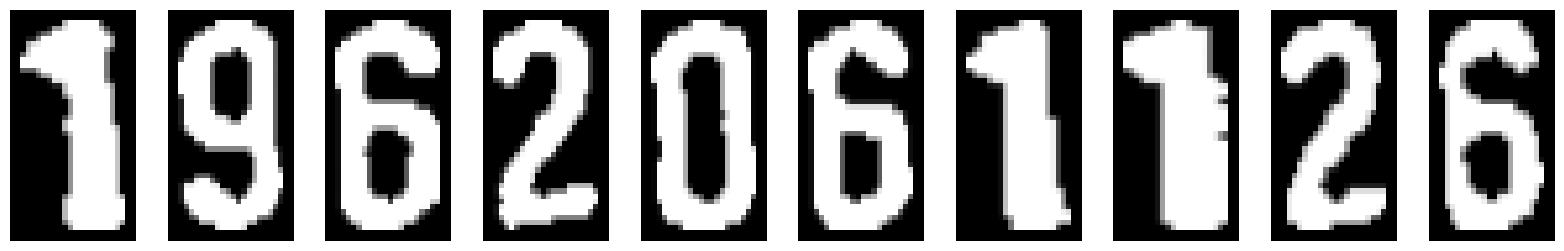

In [10]:
plate = cv2.imread('/kaggle/input/datasets/tobniislam/lp-dataset/LP Data/Images/02f2b39a-img_1876_box0.png')
visualize_segmentation(plate)

In [11]:
def evaluate_segmentation_performance(csv_path, img_dir):
    df = pd.read_csv(csv_path, dtype={'text': str})
    total_samples = len(df)
    correct_count = 0
    under_segmented = 0 # Found fewer digits than expected
    over_segmented = 0  # Found more digits than expected (noise)
    
    print(f"Evaluating {total_samples} images...")
    
    for _, row in tqdm(df.iterrows(), total=total_samples):
        img_path = os.path.join(img_dir, row['file_name'])
        image = cv2.imread(img_path)
        
        if image is None:
            continue
            
        chars = ensemble_voting_system(image)
        
        predicted_len = len(chars)
        actual_len = len(str(row['text']))
        
        if predicted_len == actual_len:
            correct_count += 1
        elif predicted_len < actual_len:
            under_segmented += 1
        else:
            over_segmented += 1
            
    accuracy = (correct_count / total_samples) * 100
    print(f"\n--- Segmentation Results ---")
    print(f"Perfect Match Accuracy: {accuracy:.2f}%")
    print(f"Under-segmented (Missed chars): {under_segmented}")
    print(f"Over-segmented (Detected noise): {over_segmented}")
    
    return accuracy

evaluate_segmentation_performance("/kaggle/input/datasets/tobniislam/updated-lp-dataset/lp_dataset.csv",
                                  "/kaggle/input/datasets/tobniislam/lp-dataset/LP Data/Images")

Evaluating 2068 images...


100%|██████████| 2068/2068 [00:36<00:00, 55.90it/s]


--- Segmentation Results ---
Perfect Match Accuracy: 74.52%
Under-segmented (Missed chars): 309
Over-segmented (Detected noise): 218


74.5164410058027

## Plate Reader

In [12]:
# Configuration + Model Loading
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Test transforms 
test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

In [13]:
class DigitClassifierTL(nn.Module): 
    def __init__(self, num_classes=10):
        super(DigitClassifierTL, self).__init__()
        self.network = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2), 
            
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2), 
            
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2), 
            
            nn.Flatten(),
            nn.Linear(128 * 28 * 28, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        return self.network(x)

In [14]:
reader_model = DigitClassifierTL().to(device)
reader_model.load_state_dict(torch.load('/kaggle/input/models/tobniislam/best-digits-seg-model/pytorch/default/1/best_digit_model.pth'))
reader_model.eval()

DigitClassifierTL(
  (network): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): Flatten(start_dim=1, end_dim=-1)
    (10): Linear(in_features=100352, out_features=256, bias=True)
    (11): ReLU()
    (12): Dropout(p=0.5, inplace=False)
    (13): Linear(in_features=256, out_features=10, bias=True)
  )
)

In [15]:
def recognize_characters(chars_list, model):
    """
    Takes a list of segmented NumPy character images and returns the predicted string.
    """
    predicted_text = ""
    confidences = []
    
    for char_np in chars_list:
        # Convert Grayscale NumPy array (44x24) to RGB PIL Image
        char_pil = Image.fromarray(char_np).convert('RGB')

        input_tensor = test_transforms(char_pil).unsqueeze(0).to(device)
        
        with torch.no_grad():
            output = model(input_tensor)
            # Get the index of the highest prediction
            probs = F.softmax(output, dim=1)
            conf, pred_label = torch.max(probs, dim=1)
            
            predicted_text += str(pred_label.item())
            confidences.append(conf.item())
            
    return predicted_text, confidences

In [16]:
# The Master Function 
def get_license_plate_text(image_path, model, integrated = False):
    """
    The full 'End-to-End' process: Path -> Image -> Segmentation -> Recognition -> Text
    Smart Repair for Algerian Plates
    """
    # Load the cropped license plate image
    if integrated:
        plate_img = image_path
    else:
        plate_img = cv2.imread(image_path) 

    if plate_img is None:
        return "Error", 0.0, 0.0
    

    # The Ensemble Voting System 
    segmented_chars = ensemble_voting_system(plate_img)
    if len(segmented_chars) == 0:
        return "", 0.0, 0.0
    # Recognition with individual digit confidences
    full_text, confs = recognize_characters(segmented_chars, reader_model)

    # EDGE CASE HANDLING 
    # CASE A: Length 9 (Aspect Ratio Split)
    if len(full_text) == 9:
        # Find the widest character 
        widths = [char.shape[1] for char in segmented_chars]
        widest_idx = np.argmax(widths)
        widest_char = segmented_chars[widest_idx]
        
        # Check aspect ratio (Width / Height)
        h, w = widest_char.shape[:2]
        if (w / h) > 0.5:  # Threshold for a 'double' digit
            # Split the widest character down the middle
            mid = w // 2
            char_left = widest_char[:, :mid]
            char_right = widest_char[:, mid:]
            
            # Re-predict the two new pieces
            text_left, conf_left = recognize_characters([char_left], reader_model)
            text_right, conf_right = recognize_characters([char_right], reader_model)
            
            # Reconstruct the list and string
            new_confs = confs[:widest_idx] + conf_left + conf_right + confs[widest_idx+1:]
            new_text = full_text[:widest_idx] + text_left + text_right + full_text[widest_idx+1:]
            
            full_text, confs = new_text, new_confs

    # CASE B: Length > 11 (Lowest Confidence Drop)
    while len(full_text) > 11:
        min_idx = np.argmin(confs)
        # Remove character and its confidence
        full_text = full_text[:min_idx] + full_text[min_idx+1:]
        confs = list(confs)
        confs.pop(min_idx)

    # CASE C: Length < 10 (Guaranteed Wrong)
    if len(full_text) < 10:
        return "", 0.0, 0.0

    # --- SMART REPAIR LOGIC ---
    text_list = list(full_text)
    plate_len = len(text_list)

    if plate_len in [10, 11]:
        try:
            #  WILAYA REPAIR 
            wilaya_val = int("".join(text_list[-2:]))
            if not (1 <= wilaya_val <= 58):
                # Rule: 8x -> 3x (81 -> 31)
                if text_list[-2] == '8':
                    text_list[-2] = '3'
                # Rule: 6x -> 0x (61 -> 01)
                elif text_list[-2] == '6':
                    text_list[-2] = '0'
                # Rule:7x -> 1x (71 -> 11)
                elif text_list[-2] == '7':
                    text_list[-2] = '1' 
                # Rule:9x -> 1x (91 -> 11)   
                elif text_list[-2] == '9':
                    text_list[-2] == '1'
                # Rule: 59 -> 51 
                elif text_list[-2:] =='59':
                    text_list[-1] = '1'

            # YEAR REPAIR 
            year_val = int("".join(text_list[-4:-2]))
            # Determine full year to check validity (1962 - 2026)
            full_year = 1900 + year_val if year_val >= 62 else 2000 + year_val
            if not (1962 <= full_year <= 2026):
                # Rule: 3x -> 8x (34 -> 84)
                if text_list[-4] == '3':
                    text_list[-4] = '8'
                # Rule: 4x -> 0x (47 -> 07)
                elif text_list[-4] == '4':
                    text_list[-4] = '0'
                # Rule: 5x -> 9x (53 -> 93)
                elif text_list[-4] == '5':
                    text_list[-4] = '9'
            
            # Re-assemble the text after potential repairs
            full_text = "".join(text_list)
        
        except ValueError:
            # In case of non-digit noise surviving
            pass
            
    avg_conf = np.mean(confs)
    min_conf = np.min(confs)

    return full_text, avg_conf, min_conf

In [17]:
def calculate_global_performance(csv_path, img_dir, model):
    
    # Load dataset
    df = pd.read_csv(csv_path, dtype={'text': str})
    total_samples = len(df)
    
    # Tracking metrics
    lev_distances = []
    perfect_matches = 0
    err_le_1 = 0  # Error <= 1
    err_le_2 = 0  # Error <= 2
    err_le_3 = 0  # Erroe <= 3
    avg_confs = []
    min_confs = []

    # Groups for visualization
    groups = {
        "correct": [],        # Distance = 0
        "near_miss": [],      # Distance 1 or 2
        "fail": []            # Distance > 2
    }

    # For Confusion Matrix
    all_true_digits = []
    all_pred_digits = []
    
    print(f"Starting Global Evaluation on {total_samples} images...")
    model.eval()

    for _, row in tqdm(df.iterrows(), total=total_samples):
        img_path = os.path.join(img_dir, row['file_name'])
        ground_truth = str(row['text']).strip()
        
        # Run the full pipeline
        try:
            predicted_text, avg_conf, min_conf = get_license_plate_text(img_path, model)
        except Exception as e:
            # Fallback for failed reads/segmentations
            predicted_text = ""
            avg_conf = 0
            min_conf = 0
        
        # Calculate Levenshtein Distance
        dist = Levenshtein.distance(predicted_text, ground_truth)
        lev_distances.append(dist)

        # Grouping Logic
        result_entry = {
            "file_name": row['file_name'],
            "true": ground_truth,
            "pred": predicted_text,
            "dist": dist,
            "avg_conf": avg_conf,
            "min_conf": min_conf
        }
        
        # Aggregate Performance
        if dist == 0:
            groups["correct"].append(result_entry)
            perfect_matches += 1
        if dist <= 1:
            err_le_1 += 1
        if dist <= 2:
            err_le_2 += 1
        if dist <=3:
            err_le_3 += 1
        if 1<=dist<=2:
            groups["near_miss"].append(result_entry)
        if dist>2:
            groups["fail"].append(result_entry)

        avg_confs.append(avg_conf)
        min_confs.append(min_conf)

        # Confusion Matrix Logic
        # We only compare digits if the lengths match to ensure correct alignment
        if len(predicted_text) == len(ground_truth):
            for t_char, p_char in zip(ground_truth, predicted_text):
                if t_char.isdigit() and p_char.isdigit():
                    all_true_digits.append(int(t_char))
                    all_pred_digits.append(int(p_char))

    # Final Metric Calculations
    acc_perfect = (perfect_matches / total_samples) * 100
    acc_le_1 = (err_le_1 / total_samples) * 100
    acc_le_2 = (err_le_2 / total_samples) * 100
    acc_le_3 = (err_le_3 / total_samples) * 100
    avg_dist = np.mean(lev_distances)
    global_avg_conf = np.mean(avg_confs) * 100
    global_min_conf = np.mean(min_confs) * 100

    # Display Results
    print("\n" + "="*40)
    print(" =======  FINAL GLOBAL RESULTS  =======")
    print("="*40)
    print(f"Total Plates Evaluated:  {total_samples}")
    print(f"Average Edit Distance:   {avg_dist:.2f} chars")
    print("-" * 40)
    print(f"- Exact Match Accuracy:      {acc_perfect:.2f}%")
    print(f"- Accuracy (≤ 1 Error):     {acc_le_1:.2f}%")
    print(f"- Accuracy (≤ 2 Errors):    {acc_le_2:.2f}%")
    print(f"- Accuracy (≤ 3 Errors):    {acc_le_3:.2f}%")
    print(f"- Global Average Confidence:    {global_avg_conf:.2f}%")
    print(f"- Global Minimum Confidence:    {global_min_conf:.2f}%")
    print("="*40)

    # --- Visualization: Confusion Matrix ---
    cm = confusion_matrix(all_true_digits, all_pred_digits, labels=list(range(10)))
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=range(10), yticklabels=range(10))
    plt.title("Digit Recognition Confusion Matrix\n(Aligned Plates Only)")
    plt.xlabel("Predicted Digit")
    plt.ylabel("True Digit")
    plt.show()

    return {
        "perfect": acc_perfect,
        "le_1": acc_le_1,
        "le_2": acc_le_2,
        "le_3": acc_le_3,
        "groups": groups
    }

Starting Global Evaluation on 2068 images...


100%|██████████| 2068/2068 [01:13<00:00, 28.10it/s]



 =======  FINAL GLOBAL RESULTS  =======
Total Plates Evaluated:  2068
Average Edit Distance:   1.72 chars
----------------------------------------
- Exact Match Accuracy:      61.46%
- Accuracy (≤ 1 Error):     72.24%
- Accuracy (≤ 2 Errors):    79.16%
- Accuracy (≤ 3 Errors):    82.88%
- Global Average Confidence:    90.30%
- Global Minimum Confidence:    81.12%


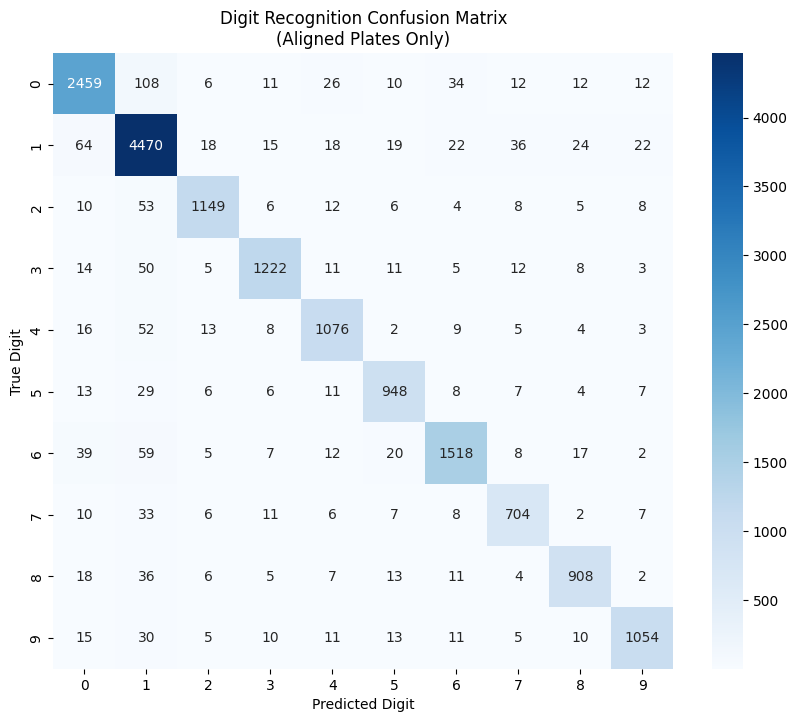

In [18]:
# Execute the evaluation
results = calculate_global_performance(
    "/kaggle/input/datasets/tobniislam/updated-lp-dataset/lp_dataset.csv",
    "/kaggle/input/datasets/tobniislam/lp-dataset/LP Data/Images",
    reader_model
)

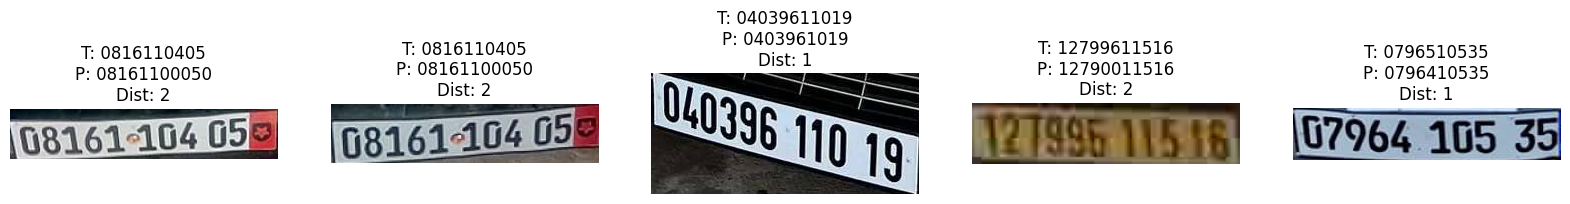

In [19]:
def visualize_error_group(group_list, img_dir, num_samples=5):

    samples = random.sample(group_list, min(num_samples, len(group_list)))
    
    plt.figure(figsize=(20, 4))
    for i, item in enumerate(samples):
        img_path = os.path.join(img_dir, item['file_name'])
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        plt.subplot(1, num_samples, i+1)
        plt.imshow(img)
        plt.title(f"T: {item['true']}\nP: {item['pred']}\nDist: {item['dist']}")
        plt.axis('off')
    plt.show()

visualize_error_group(results['groups']["near_miss"], 
                      "/kaggle/input/datasets/tobniislam/lp-dataset/LP Data/Images")

📊 Analyzing 2143 images...


100%|██████████| 2143/2143 [01:14<00:00, 28.88it/s]


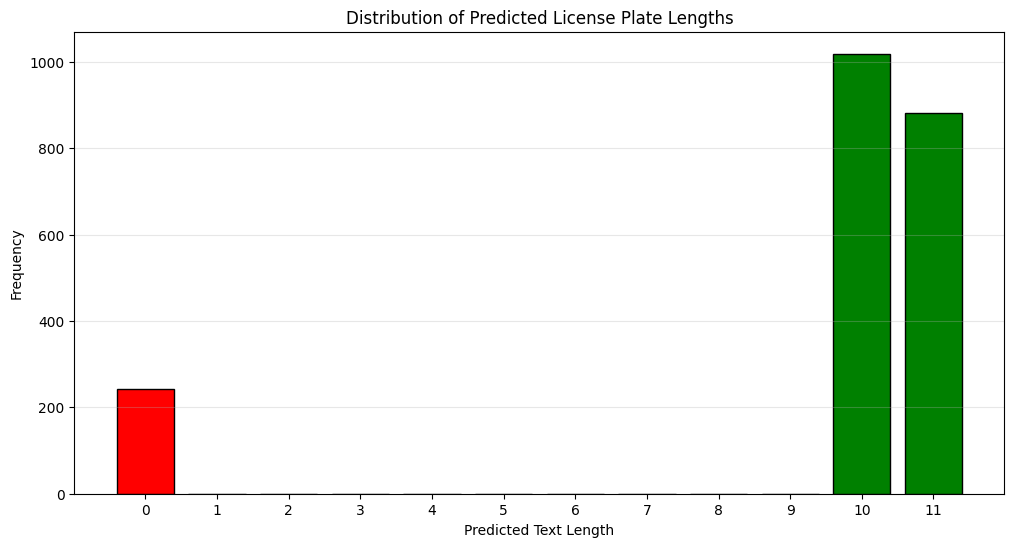

In [20]:
def analyze_prediction_lengths(img_dir, model):
    lengths = []
    image_files = [f for f in os.listdir(img_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    
    print(f"📊 Analyzing {len(image_files)} images...")
    
    for filename in tqdm(image_files):
        img_path = os.path.join(img_dir, filename)
        
        # We call the function exactly as you provided
        # Note: Ensure 'reader_model' and 'ensemble_voting_system' are in scope
        try:
            pred_text, _, _ = get_license_plate_text(img_path, model, integrated=False)
            lengths.append(len(pred_text))
        except Exception as e:
            lengths.append(0) # Categorize errors as length 0

    # Plotting the Histogram
    plt.figure(figsize=(12, 6))
    counts, bins, patches = plt.hist(lengths, bins=range(min(lengths), max(lengths) + 2), 
                                     align='left', rwidth=0.8, color='skyblue', edgecolor='black')
    
    plt.xticks(range(min(lengths), max(lengths) + 1))
    plt.xlabel('Predicted Text Length')
    plt.ylabel('Frequency')
    plt.title('Distribution of Predicted License Plate Lengths')
    
    # Highlight the target zone (10-11)
    for i in range(len(bins)-1):
        if bins[i] in [10, 11]:
            patches[i].set_facecolor('green')
        elif bins[i] == 12:
            patches[i].set_facecolor('orange')
        elif bins[i] < 10 or bins[i] > 12:
            patches[i].set_facecolor('red')

    plt.grid(axis='y', alpha=0.3)
    plt.show()
    
    return lengths

# Execute
results_lengths = analyze_prediction_lengths("/kaggle/input/datasets/tobniislam/lp-dataset/LP Data/Images", reader_model)

In [21]:
values, counts = np.unique(results_lengths, return_counts=True)
for value, count in dict(zip(values, counts)).items():
    print(f"length {value} : {count} times")

length 0 : 242 times
length 10 : 1019 times
length 11 : 882 times


## Postprocessing

In [22]:
def parse_plate_text(raw_text, confidences):
    """
    Post-processes the raw digit string based on Algerian constraints.
    
    Args:
        raw_text (str): The predicted string '12345612216'
        confidences (list): List of floats for each digit's confidence
        
    Returns:
        dict: Processed results including validation flags
    """
    # Initialize result
    result = {
        "wilaya": None,
        "serial": None,
        "year": None,
        "vehicule_type": None,
        "raw_text": raw_text,
        "seg_confidence": np.mean(confidences) if confidences else 0,
        "parse_success": False,
        "error_msg": ""
    }

    # Length Constraint (10 or 11 digits)
    plate_len = len(raw_text)
    if plate_len not in [10, 11]:
        result["error_msg"] = f"Invalid length: {plate_len}"
        return result

    try:
        # 2. Slicing logic (Work backwards from the end)
        # Last 2 = Wilaya
        # 2 before that = Year
        # 1 before that = Type
        # Everything else = Serial
        
        raw_wilaya = raw_text[-2:]
        raw_year = raw_text[-4:-2]
        raw_type = raw_text[-5:-4]
        raw_serial = raw_text[:-5]

        # Validation: Wilaya (01 -> 58) 
        wilaya_int = int(raw_wilaya)
        if not (1 <= wilaya_int <= 58):
            result["error_msg"] = f"Invalid Wilaya: {raw_wilaya}"
            return result

        # Validation: Year (No car before 1962) 
        year_short = int(raw_year)
        current_year = datetime.now().year # 2026
        
        # Determine century
        if year_short >= 62:
            full_year = 1900 + year_short
        else:
            full_year = 2000 + year_short
            
        if full_year > current_year:
            result["error_msg"] = f"Future year detected: {full_year}"
            return result

        # Finalizing Data
        result["wilaya"] = raw_wilaya 
        result["year"] = str(full_year)
        result["vehicule_type"] = raw_type
        result["serial"] = raw_serial
        result["parse_success"] = True
        
    except ValueError:
        result["error_msg"] = "Non-digit characters encountered"

    return result

Detected Plate: 2097091240
Average Confidence: 92.89%
Minimum Confidence: 51.21%


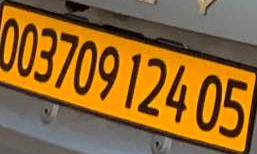

In [23]:
img_path = '/kaggle/input/datasets/tobniislam/lp-dataset/LP Data/Images/0367cfeb-img_1000_box0.png'
img_path_err = '/kaggle/input/datasets/tobniislam/lp-dataset/LP Data/Images/1a482c49-img_0273_box0.png'
plate_text, avg_conf, min_conf = get_license_plate_text(img_path_err, reader_model)
print(f"Detected Plate: {plate_text}")
print(f"Average Confidence: {avg_conf*100:.2f}%")
print(f"Minimum Confidence: {min_conf*100:.2f}%")
Image.open(img_path_err)

In [24]:
post_result = parse_plate_text(plate_text, min_conf)
for key, value in post_result.items():
    print(f"{key}:  {value}")

wilaya:  40
serial:  20970
year:  2012
vehicule_type:  9
raw_text:  2097091240
seg_confidence:  0.5120515823364258
parse_success:  True
error_msg:  


In [25]:
def format_algerian_plate(raw_text):
    """
    Separates an Algerian license plate into: Serial-TypeYear-Wilaya
    Example: '12345612216' -> '123456-122-16'
    """
    if not raw_text or len(raw_text) < 6:
        return raw_text 

    # Wilaya
    wilaya = raw_text[-2:]
    
    # Type + Year
    type_year = raw_text[-5:-2]
    
    # Serial Number 
    serial = raw_text[:-5]
    
    return f"{serial}-{type_year}-{wilaya}"

## Pipeline

In [26]:
def run_pipeline(
    image_path,
    model,
    reader,
    confidence_threshold,
):
    """
    Full pipeline: image path → list of structured plate dicts.
    One dict per detected plate.
    """
    t_start = time.time()
    image = cv2.imread(image_path)
    if image is None:
        return []

    results = model(image_path, verbose=False, conf=confidence_threshold)
    plates = []

    for r in results:
        for box in r.boxes:
            x1, y1, x2, y2 = map(int, box.xyxy[0])
            det_conf = float(box.conf[0])

            plate_img = crop_plate(
                image,
                (x1, y1, x2, y2),
            )
            raw_text, avg_conf, min_conf = get_license_plate_text(plate_img, reader, True)
            parsed = parse_plate_text(raw_text, min_conf)

            global_conf = det_conf * min_conf

            parsed["bbox"] = [x1, y1, x2, y2]
            parsed["det_conf"] = round(det_conf, 4)
            parsed['confidence'] = round(global_conf, 4)
            parsed["latency_ms"] = round((time.time() - t_start) * 1000, 1)

            plates.append(parsed)

    return plates

In [27]:
detection_model = YOLO('/kaggle/input/models/tobniislam/best-detection-model/pytorch/default/1/best_detection_model.pt')

✅ Prediction: 424826-021-36
- Wilaya: 36
- Year:  2021
- Confidence:  69.53%
- Detection Confidence: 88.76%
- Segmentation Confidence: 78.33%
====================  Image  ====================


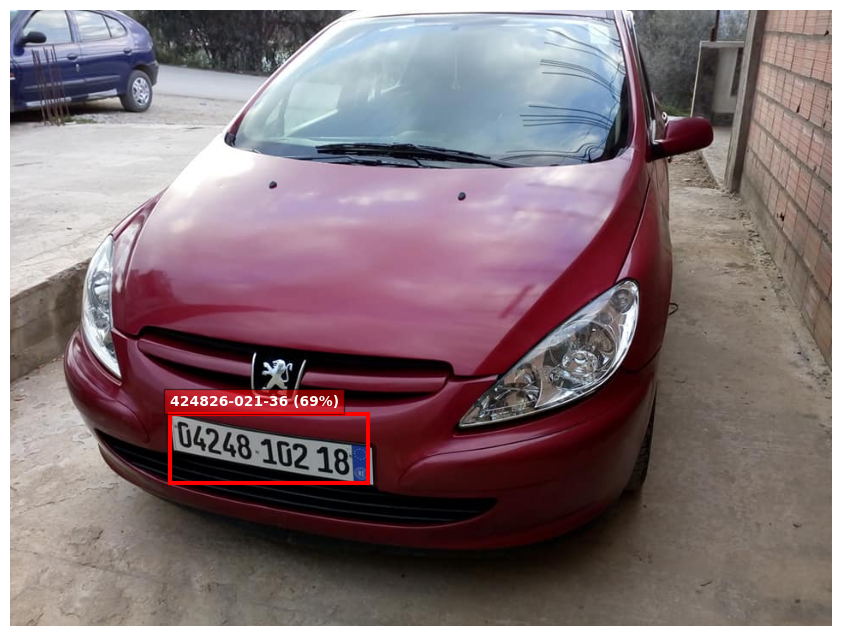

In [28]:
image_test_path = Path("/kaggle/input/datasets/tobniislam/cars-with-plates-dataset/images/test/0864067a-img_1456.jpg")
CONF_THRESH = 0.4

results = run_pipeline(str(image_test_path), detection_model, reader_model, CONF_THRESH)

if len(results) == 0:
    print("======= No License Plate Detected! =======")
    
    # Load the image for plotting
    img = plt.imread(image_test_path)
    plt.figure(figsize=(12, 8))
    plt.imshow(img)
    plt.axis('off')
    plt.show()

# Display results
for plate in results:
    print(f"✅ Prediction: {format_algerian_plate(plate['raw_text'])}")
    print(f"- Wilaya: {plate['wilaya']}")
    print(f"- Year:  {plate['year']}")
    print(f"- Confidence:  {plate['confidence']*100:.2f}%")
    print(f"- Detection Confidence: {plate['det_conf']*100:.2f}%")
    print(f"- Segmentation Confidence: {plate['seg_confidence']*100:.2f}%")
    print(f"====================  Image  ====================")
    
    # Load the image for plotting
    img = plt.imread(image_test_path)
    plt.figure(figsize=(12, 8))
    plt.imshow(img)
    
    # Draw the bounding box (from YOLO)
    x1, y1, x2, y2 = plate['bbox']
    rect = plt.Rectangle((x1, y1), x2-x1, y2-y1, fill=False, color='red', linewidth=3)
    plt.gca().add_patch(rect)
    
    # Add a text label above the box
    label = f"{format_algerian_plate(plate['raw_text'])} ({int(plate['confidence']*100)}%)"
    plt.text(x1, y1-10, label, color='white', weight='bold', 
             bbox=dict(facecolor='red', alpha=0.5))
    
    plt.axis('off')
    plt.show()

In [29]:
class PlateReader:
    def __init__(self, model_path, device=None):
        self.device = (
            device
            if device
            else torch.device("cuda" if torch.cuda.is_available() else "cpu")
        )

        # Load Model
        self.model = DigitClassifierTL().to(self.device)
        self.model.load_state_dict(torch.load(model_path, map_location=self.device))
        self.model.eval()

        # Define Transforms
        self.transforms = transforms.Compose(
            [
                transforms.Resize((224, 224)),
                transforms.ToTensor(),
                transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
            ]
        )

    def _recognize_characters(self, chars_list):
        """Internal helper for digit classification."""
        predicted_text = ""
        confidences = []

        for char_np in chars_list:
            char_pil = Image.fromarray(char_np).convert("RGB")
            input_tensor = self.transforms(char_pil).unsqueeze(0).to(self.device)

            with torch.no_grad():
                output = self.model(input_tensor)
                probs = F.softmax(output, dim=1)
                conf, pred_label = torch.max(probs, dim=1)

                predicted_text += str(pred_label.item())
                confidences.append(conf.item())

        return predicted_text, confidences

    def _apply_smart_repair(self, text_list):
        """Internal logic for Algerian plate semantic rules."""
        try:
            # Wilaya Repair
            wilaya_val = int("".join(text_list[-2:]))
            if not (1 <= wilaya_val <= 58):
                if text_list[-2] == "8":
                    text_list[-2] = "3"
                elif text_list[-2] == "6":
                    text_list[-2] = "0"
                elif text_list[-2] == "7":
                    text_list[-2] = "1"
                elif text_list[-2] == "9":
                    text_list[-2] = "1"
                elif "".join(text_list[-2:]) == "59":
                    text_list[-1] = "1"

            # Year Repair
            year_val = int("".join(text_list[-4:-2]))
            full_year = 1900 + year_val if year_val >= 62 else 2000 + year_val
            if not (1962 <= full_year <= 2026):
                if text_list[-4] == "3":
                    text_list[-4] = "8"
                elif text_list[-4] == "4":
                    text_list[-4] = "0"
                elif text_list[-4] == "5":
                    text_list[-4] = "9"
        except (ValueError, IndexError):
            pass
        return "".join(text_list)

    def read(self, plate_img):
        """Production method: Returns text, avg_conf, min_conf."""
        # Segmentation
        segmented_chars = ensemble_voting_system(plate_img)
        if not segmented_chars:
            return "", 0.0, 0.0

        # Recognition
        text, confs = self._recognize_characters(segmented_chars)

        # Edge Case: Length 9 (Aspect Ratio Split)
        if len(text) == 9:
            widths = [c.shape[1] for c in segmented_chars]
            idx = np.argmax(widths)
            h, w = segmented_chars[idx].shape[:2]
            if (w / h) > 0.5:
                mid = w // 2
                t_l, c_l = self._recognize_characters([segmented_chars[idx][:, :mid]])
                t_r, c_r = self._recognize_characters([segmented_chars[idx][:, mid:]])
                text = text[:idx] + t_l + t_r + text[idx + 1 :]
                confs = confs[:idx] + c_l + c_r + confs[idx + 1 :]

        # Edge Case: Length > 11 (Lowest Confidence Drop)
        while len(text) > 11:
            min_idx = np.argmin(confs)
            text = text[:min_idx] + text[min_idx + 1 :]
            confs.pop(min_idx)

        # Integrity Check
        if len(text) < 10:
            return "", 0.0, 0.0

        # Smart Repair
        final_text = self._apply_smart_repair(list(text))

        return final_text, np.mean(confs), np.min(confs)

    def read_debug(self, plate_img):
        """Diagnostic method: Returns detailed dictionary of the process."""
        segmented_chars = ensemble_voting_system(plate_img)
        raw_text, confs = self._recognize_characters(segmented_chars)

        # Capture state before repairs
        debug_info = {
            "initial_segment_count": len(segmented_chars),
            "raw_prediction": raw_text,
            "raw_confidences": confs,
            "final_text": "",
            "status": "Success",
        }

        final_text, avg_c, min_c = self.read(plate_img)

        debug_info["final_text"] = final_text
        debug_info["avg_conf"] = avg_c
        debug_info["min_conf"] = min_c

        if final_text == "" and len(raw_text) > 0:
            debug_info["status"] = "Rejected by Integrity Guard (Length < 10)"
        elif not segmented_chars:
            debug_info["status"] = "Failed: No characters segmented"

        return debug_info

In [31]:
def char_accuracy(predicted: str, ground_truth: str) -> tuple[int, int]:
    correct = sum(p == g for p, g in zip(predicted, ground_truth))
    total = max(len(predicted), len(ground_truth))
    return correct, total


def main(gt_csv: str, weights: str) -> None:
    model = YOLO(weights)
    reader = PlateReader("/kaggle/input/models/tobniislam/best-digits-seg-model/pytorch/default/1/best_digit_model.pth")
    img_dir = Path("/kaggle/input/datasets/tobniislam/ground-truth-images")

    serial_correct = serial_total = 0
    wilaya_correct = wilaya_total = 0
    full_match = 0
    rows_evaluated = 0

    with open(gt_csv) as f:
        for row in csv.DictReader(f):
            img_path = img_dir / row["filename"]
            if not img_path.exists():
                print(f"SKIP (not found): {row['filename']}")
                continue
            results = run_pipeline(str(img_path), model, reader, 0.4)
            if not results:
                print(f"NO DETECTION: {row['filename']}")
                continue

            pred = results[0]
            sc, st = char_accuracy(pred["serial"], row["serial"])
            wc, wt = char_accuracy(pred["wilaya"], row["wilaya"])
            serial_correct += sc; serial_total += st
            wilaya_correct += wc; wilaya_total += wt
            if pred["serial"] == row["serial"] and pred["wilaya"] == row["wilaya"]:
                full_match += 1
            rows_evaluated += 1
            print(f"{row['filename']}: serial={pred['serial']!r}(gt={row['serial']!r}) "
                  f"wilaya={pred['wilaya']!r}(gt={row['wilaya']!r})")

    print(f"\n=== OCR ACCURACY ({rows_evaluated} plates) ===")
    if serial_total:
        print(f"Latin serial accuracy:  {serial_correct/serial_total*100:.1f}%  ({serial_correct}/{serial_total} chars)")
    if wilaya_total:
        print(f"Arabic wilaya accuracy: {wilaya_correct/wilaya_total*100:.1f}%  ({wilaya_correct}/{wilaya_total} chars)")
    print(f"Full plate match:       {full_match/rows_evaluated*100:.1f}%  ({full_match}/{rows_evaluated} plates)")



main("/kaggle/input/datasets/tobniislam/ocr-ground-truth/ocr_ground_truth.csv", 
         "/kaggle/input/models/tobniislam/best-detection-model/pytorch/default/1/best_detection_model.pt")

img_1566.jpg: serial='010971'(gt='010971') wilaya='16'(gt='16')
img_1564.jpg: serial='24031'(gt='24031') wilaya='41'(gt='06')
img_1563.jpg: serial='045213'(gt='04521') wilaya='54'(gt='25')
img_1583.jpg: serial='07911'(gt='07911') wilaya='18'(gt='18')
img_1574.jpg: serial='18941'(gt='18941') wilaya='09'(gt='09')
img_1607.jpg: serial='029411'(gt='02941') wilaya='36'(gt='18')
img_1759.jpg: serial='09972'(gt='09972') wilaya='18'(gt='18')
img_1814.jpg: serial='00399'(gt='00399') wilaya='18'(gt='18')
img_1840.jpg: serial='106472'(gt='106472') wilaya='16'(gt='16')
img_0841.jpg: serial='37693'(gt='37693') wilaya='16'(gt='16')
img_0719.jpg: serial='49207'(gt='49207') wilaya='16'(gt='16')
img_0377.jpg: serial='003055'(gt='003055') wilaya='05'(gt='05')
img_0305.jpg: serial='142606'(gt='142606') wilaya='16'(gt='16')
img_0893.jpg: serial='051623'(gt='051623') wilaya='16'(gt='16')
img_1812.jpg: serial='15983'(gt='15983') wilaya='35'(gt='35')
img_1829.jpg: serial='011043'(gt='01104') wilaya='18'(gt='